# Dataset Exploration — Caratterizzazione della lesione e criteri di ammissione

Parte 2 di 3 (vedi anche `dataset_availability.ipynb` e `clinical_metadata_raw.ipynb`).

In [20]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from collections import defaultdict

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Path dinamici relativi alla posizione del progetto
project_root = '/Users/emmatosato/Local Projects/Local PhD Projects/NEMESIS_fs'
DERIV_ROOT = Path(project_root) / "data" / "clinical_connectome" / "derivatives"


## Caratterizzazione della lesione e criteri di ammissione soggetti

**Obiettivo della sezione**

Questa sezione analizza la **qualità delle lesion mask** per capire quali soggetti sono candidati a essere esclusi dalle pipeline di embedding/clustering, lungo tre assi:

- **volume** — quanto è estesa la lesione (voxel troppo pochi sono spesso un errore di segmentazione, non un dato reale)
- **lateralità** — in quale emisfero cade la lesione
- **contaminazione extra-cerebrale** — quanti voxel della maschera cadono fuori dal cervello (indizio di un errore di normalizzazione)

Per ciascun asse si calcola la **distribuzione** sui dati reali e si propone una **soglia candidata**, ma nessuna soglia viene applicata qui: questa è un'analisi esplorativa, non un filtro — l'esclusione effettiva resta una decisione separata, da prendere a valle.

Copre i dataset presenti in `assets/metadata/participants.csv` (il registro clinico canonico), non necessariamente tutti quelli visti in `dataset_availability.ipynb`.

### Utilità di plotting

`dataset_grid(n)` crea una griglia di subplot (righe × colonne, non una singola riga) per confrontare i dataset — usata in tutte le sezioni sotto.

In [21]:
import numpy as np

def dataset_grid(n_items: int, n_cols: int = 3, subplot_size: tuple[float, float] = (4, 4)):
    """Griglia n_rows x n_cols di assi (un subplot per dataset), assi in eccesso nascosti."""
    n_rows = -(-n_items // n_cols)  # ceil division
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(subplot_size[0] * n_cols, subplot_size[1] * n_rows))
    axes = np.array(axes).reshape(-1)
    for ax in axes[n_items:]:
        ax.set_visible(False)
    return fig, axes[:n_items]


### Volume della lesione

Le misure fatte sulle maschere vivono in `assets/metadata/lesion_metadata.csv`, scritto da `src/pipeline/compute_lesion_metadata.py`: una riga per ogni soggetto con maschera, **nessuna soglia applicata**, e quattro colonne per ogni griglia di voxel — volume, frazione fuori dal brain, indice di lateralità e lato.

`assets/metadata/participants.csv` resta la fonte di verità per i dati anagrafici/clinici, e da lì si prende `lesion_side`/`lesion_side_source` (il lato clinico, dove esiste). Le due tabelle si uniscono su `subject_id`.

**Come si calcolano i volumi, e perché sono due**

Le maschere manuali sono a **1 mm nativo**. La griglia `2mm` è quella di produzione (`build_lesion_matrix.py`), e ci si arriva con un ricampionamento `nearest` che tiene un voxel su 8: il conteggio a 1 mm è esatto, quello a 2 mm è un sottocampionamento in cui una lesione minuscola può ridursi o sparire. Confrontare le due colonne è l'unico modo per dire se una maschera a 0 voxel a 2 mm sia vuota nel file originale o abbia perso la lesione nel ricampionamento.

Entrambi i volumi sono contati **dopo** l'azzeramento dei voxel fuori dal cervello; `out_of_brain_fraction_*` è invece misurata **prima**, sulla maschera grezza — è la colonna che serve a decidere chi escludere, e la correzione la porterebbe a 0 per costruzione.

**Obiettivo**: capire quanto è comune una lesione molto piccola, e decidere quali soggetti tenere fuori dalle matrici di produzione.

In [ ]:
LESION_METADATA_PATH = Path(project_root) / "assets" / "metadata" / "lesion_metadata.csv"
PARTICIPANTS_PATH = Path(project_root) / "assets" / "metadata" / "participants.csv"

lesion_metrics = pd.read_csv(LESION_METADATA_PATH)
participants = pd.read_csv(PARTICIPANTS_PATH)

# Le misure sulle maschere vengono dal csv dedicato; dal registro si prende solo il lato clinico.
# participants.csv ne tiene una copia (lesion_volume_voxels_2mm, lesion_side), ma la fonte delle
# misure e' questo csv: ha tutte le griglie e tutte le metriche, il registro solo un sottoinsieme.
participants_lesion = lesion_metrics.merge(
    participants[["subject_id", "lesion_side", "lesion_side_source"]], on="subject_id", how="left"
)
participants_lesion["log1p_lesion_volume_voxels"] = np.log1p(participants_lesion["lesion_volume_voxels_2mm"])

unknown = set(participants_lesion["subject_id"]) - set(participants["subject_id"])
assert not unknown, f"{len(unknown)} soggetti in lesion_metadata.csv non sono nel registro: {sorted(unknown)[:5]}"

print(f"{len(participants_lesion)} soggetti con maschera misurata, su {len(participants)} totali in participants.csv")
print(f"griglie disponibili: {sorted(c.removeprefix('lesion_volume_voxels_') for c in lesion_metrics.columns if c.startswith('lesion_volume_voxels_'))}")

#### Distribuzione del volume

**Cosa fa questa cella**

Disegna un **istogramma** della distribuzione del volume di lesione (in scala `log1p`), **un subplot per dataset**, usando la griglia definita da `dataset_grid`.

Ogni subplot ha nel titolo il **nome del dataset** e il numero di soggetti (`n=`), utile per confrontare a colpo d'occhio forma e ampiezza della distribuzione tra le diverse coorti.

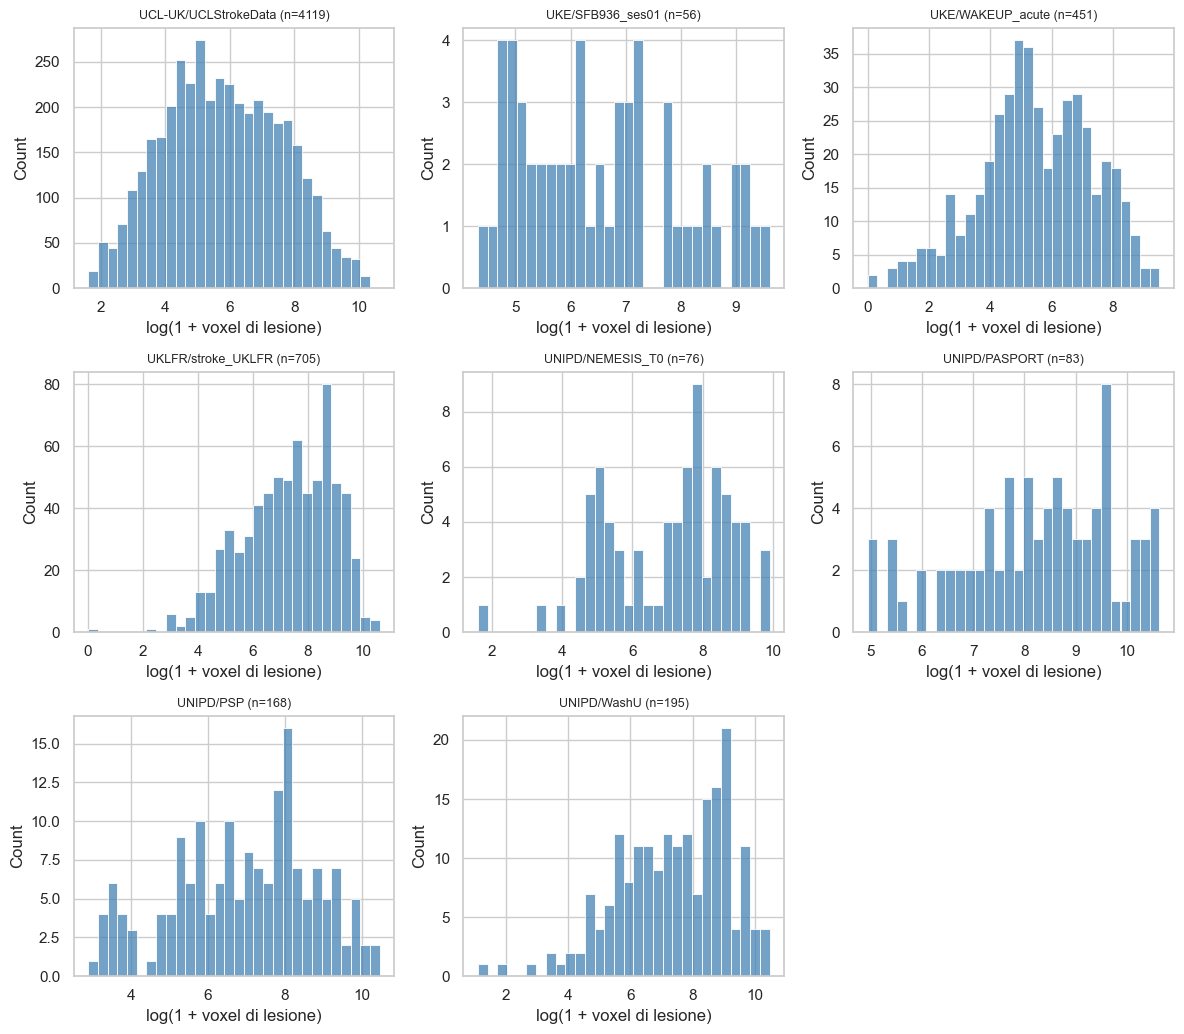

In [23]:
fig, axes = dataset_grid(participants_lesion["dataset"].nunique(), n_cols=3, subplot_size=(4, 3.5))

for ax, (name, group) in zip(axes, participants_lesion.groupby("dataset")):
    sns.histplot(group["log1p_lesion_volume_voxels"], bins=30, color="steelblue", ax=ax)
    ax.set_title(f"{name} (n={len(group)})", fontsize=9)
    ax.set_xlabel("log(1 + voxel di lesione)")

plt.tight_layout()
plt.show();


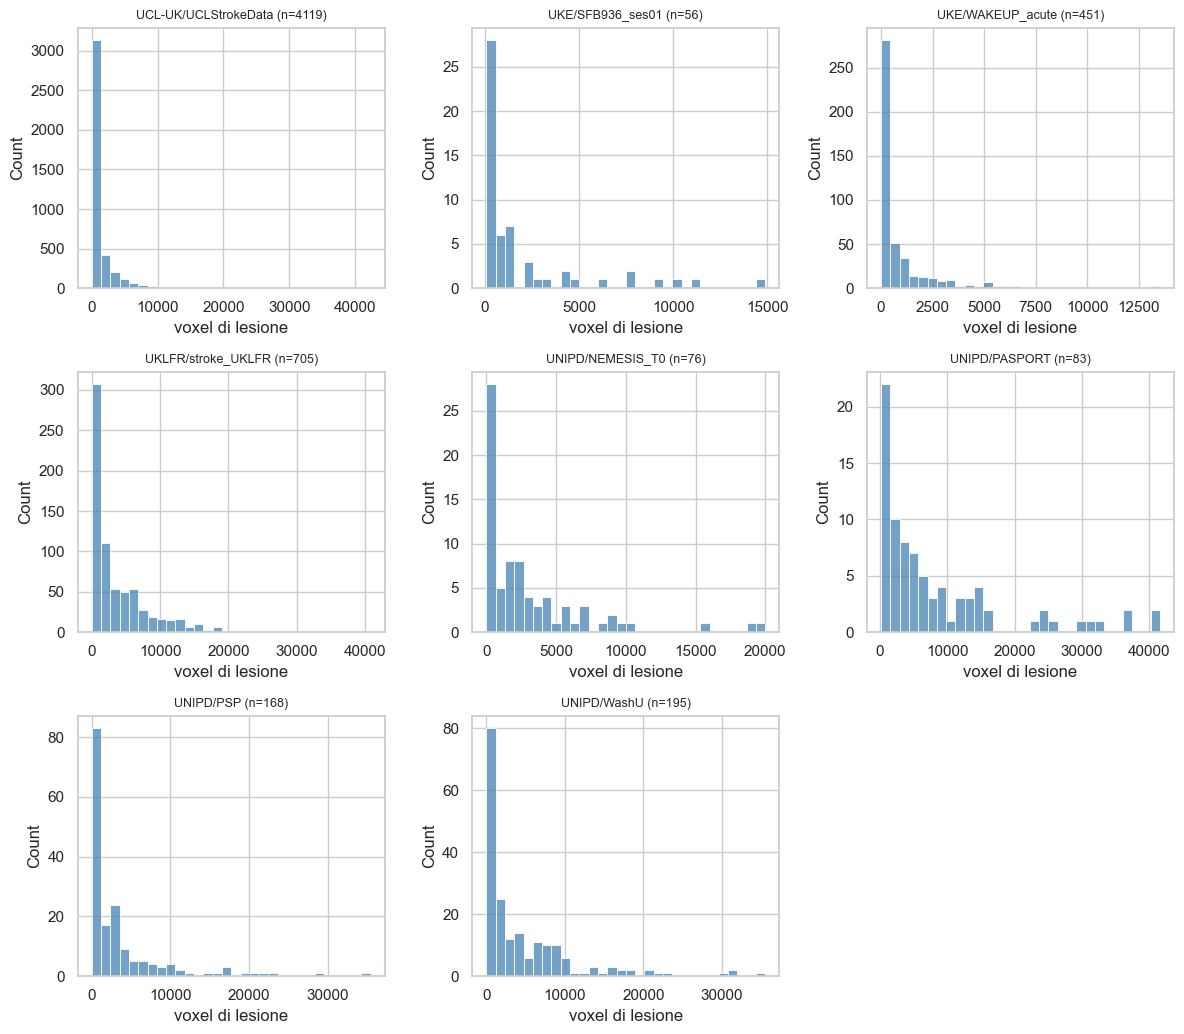

In [24]:
fig, axes = dataset_grid(participants_lesion["dataset"].nunique(), n_cols=3, subplot_size=(4, 3.5))

for ax, (name, group) in zip(axes, participants_lesion.groupby("dataset")):
    sns.histplot(group["lesion_volume_voxels_2mm"], bins=30, color="steelblue", ax=ax)
    ax.set_title(f"{name} (n={len(group)})", fontsize=9)
    ax.set_xlabel("voxel di lesione")

plt.tight_layout()
plt.show();

#### Maschere vuote (volume = 0)

Cerca i soggetti la cui maschera non ha **nessun voxel di lesione** (`lesion_volume_voxels_2mm == 0`) dopo binarizzazione e ricampionamento sulla griglia comune. Sono i casi più netti da escludere: senza lesione non c'è nulla da embeddare.

In [ ]:
# Maschere vuote, sulle due griglie: un volume 0 a 2 mm non implica una maschera vuota all'origine.
empty_2mm = participants_lesion["lesion_volume_voxels_2mm"] == 0
empty_1mm = participants_lesion["lesion_volume_voxels_1mm"] == 0

# empty_masks resta il nome usato dalle celle successive: sono le vuote sulla griglia di produzione.
empty_masks = participants_lesion[empty_2mm]

print(f"{int(empty_1mm.sum())}/{len(participants_lesion)} maschere vuote a 1 mm (vuote davvero: nessun voxel nel file originale)")
print(f"{int(empty_2mm.sum())}/{len(participants_lesion)} maschere vuote a 2 mm (griglia di produzione)")
print(f"{int((empty_2mm & ~empty_1mm).sum())} soggetti hanno perso l'intera lesione nel ricampionamento a 2 mm\n")

display(
    participants_lesion.loc[empty_2mm | empty_1mm, ["subject_id", "dataset", "lesion_volume_voxels_1mm", "lesion_volume_voxels_2mm"]]
    .sort_values("lesion_volume_voxels_1mm")
    .reset_index(drop=True)
)

#### Elenco maschere vuote

Elenco puntuale dei soggetti in `empty_masks` (calcolato nella cella sopra) — utile per ispezionarli uno a uno (es. aprire la maschera originale e verificare se è vuota già nel file nativo o se la lesione si perde nel ricampionamento).

In [ ]:
display(
    empty_masks[["subject_id", "dataset", "lesion_volume_voxels_1mm", "lesion_volume_voxels_2mm"]]
    .reset_index(drop=True)
)

#### Soglia IQR per dataset

**Che cos'è la soglia**

Un limite di volume, in voxel, sotto il quale una lesione è considerata **anomala rispetto agli altri soggetti dello stesso dataset**. Non dice "lesione troppo piccola in assoluto": dice "molto più piccola del normale per questa coorte". Ogni dataset ha la sua, perché le coorti hanno volumi tipici molto diversi (centinaia di voxel in alcuni, migliaia in altri) e una soglia unica colpirebbe le coorti in modo sbilanciato.

**Come si calcola** (separatamente per ogni dataset)

0. **Le maschere vuote (0 voxel) sono già state trovate** nelle celle "Maschere vuote" sopra e qui vengono **tolte** dal test. Un volume 0 è un caso di per sé, non una lesione piccola, e su scala log (`log1p(0) = 0`) trascinerebbe in basso Q1 e IQR, falsando la soglia per gli altri soggetti. Serve quindi aver eseguito prima quelle celle.
1. Il volume in voxel viene trasformato con `log1p` (`log(1 + volume)`): i volumi sono molto sbilanciati (pochi molto grandi), e su scala log la distribuzione è più simmetrica.
2. `Q1` è il valore sotto cui sta il 25% dei soggetti, `Q3` quello sotto cui sta il 75%. L'`IQR` (`Q3 − Q1`) è l'ampiezza della parte centrale della distribuzione.
3. Limite inferiore = `Q1 − 1.5 × IQR` (regola di Tukey, la convenzione standard per gli outlier). Il risultato viene riportato in voxel.
4. Sono "sotto soglia" i soggetti con `volume < limite`.

**Come leggere l'output**

- **Tabella per dataset:** `n (senza vuote)` (soggetti nel test), `soglia (voxel)` (il limite del dataset) e `n_sotto_soglia`. Una soglia sotto 1 significa che nessuna lesione con almeno 1 voxel è anomala per quel dataset.
- **Tabella con gli ID**, come nel test globale originale: soggetti sotto soglia raggruppati per dataset.
- **Riquadro scorrevole:** gli stessi ID ordinati per volume crescente.
- Più un dataset ha molte lesioni piccole, più il suo limite scende: il criterio è relativo ai dati stessi, non a un volume clinicamente sensato.

Nessuna soglia viene applicata: è solo esplorazione.

In [ ]:
from IPython.display import HTML, display
import html


def show_scrollable(text: str, max_height_px: int = 220) -> None:
    """Mostra `text` in un riquadro a scorrimento verticale (utile per liste lunghe di ID)."""
    display(HTML(
        f'<div style="max-height:{max_height_px}px;overflow-y:auto;border:1px solid #999;padding:6px;'
        f'font-family:monospace;font-size:12px;white-space:pre">{html.escape(text)}</div>'
    ))


# Le maschere vuote (empty_masks, cella "Maschere vuote" sopra) non entrano nel test
participants_nonempty = participants_lesion.drop(index=empty_masks.index)

# Tukey IQR sulla trasformata log1p, calcolato separatamente in ogni dataset
rows, flagged = [], []
for name, group in participants_nonempty.groupby("dataset"):
    log_vol = group["log1p_lesion_volume_voxels"]
    q1, q3 = log_vol.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower_bound_voxels = np.expm1(q1 - 1.5 * iqr)
    below = group[group["lesion_volume_voxels_2mm"] < lower_bound_voxels]
    flagged.append(below)
    rows.append({
        "dataset": name,
        "n (senza vuote)": len(group),
        "Q1 (voxel)": np.expm1(q1),
        "Q3 (voxel)": np.expm1(q3),
        "soglia (voxel)": lower_bound_voxels,
        "n_sotto_soglia": len(below),
    })

iqr_per_dataset = pd.DataFrame(rows).set_index("dataset")
very_small_per_dataset = pd.concat(flagged)

print("Soglia IQR per dataset (1.5x IQR sotto Q1, su scala log1p), maschere vuote escluse:")
display(iqr_per_dataset.round(1))

print(f"\n{len(very_small_per_dataset)}/{len(participants_nonempty)} soggetti sotto la soglia del proprio dataset, per dataset:")
display(
    very_small_per_dataset.groupby("dataset")["subject_id"]
    .agg(n_soggetti="count", subject_id=list)
)

show_scrollable("\n".join(
    f"{r.subject_id}\t{r.dataset}\t{int(r.lesion_volume_voxels_2mm)} voxel"
    for r in very_small_per_dataset.sort_values("lesion_volume_voxels_2mm").itertuples()
))

#### Soglia a quantile fisso

**Che cos'è la soglia**

Il volume sotto il quale sta una **quota fissata** di soggetti. Con `QUANTILE = 0.02` la soglia è il 2° percentile dei volumi: il 2% dei soggetti con lesione più piccola, calcolato su tutti i dataset insieme, cade sotto soglia.

**Differenza dall'IQR**

- L'IQR è un test statistico: segnala solo chi è anomalo, e può non segnalare nessuno (o solo le maschere vuote, come qui).
- Il quantile fisso **segnala sempre esattamente quella quota di soggetti**, anche se nessuno è davvero anomalo. La distribuzione dei volumi piccoli è continua, senza un salto naturale, quindi la scelta del quantile è una decisione, non un risultato.

**Cosa mostra la cella**

Una tabella con alcuni quantili a confronto (soglia in voxel e soggetti sotto soglia), poi, per il `QUANTILE` scelto, il conteggio per dataset e gli ID in un riquadro scorrevole. Regola: `volume < soglia`. Nessuna soglia viene applicata qui: serve a scegliere quali ID mettere nella cella finale, che scrive il file degli esclusi.

In [ ]:
QUANTILE = 0.02  # da modificare: quota di soggetti (sui volumi piu' piccoli) da segnalare

volumes = participants_lesion["lesion_volume_voxels_2mm"]
display(pd.DataFrame(
    [{"quantile": q, "soglia (voxel)": volumes.quantile(q), "n_sotto_soglia": int((volumes < volumes.quantile(q)).sum())}
     for q in [0.01, 0.02, 0.05, 0.10]]
).set_index("quantile"))

quantile_threshold = volumes.quantile(QUANTILE)
below_quantile = participants_lesion[volumes < quantile_threshold].sort_values("lesion_volume_voxels_2mm")
print(f"QUANTILE={QUANTILE}: soglia {quantile_threshold:.1f} voxel, {len(below_quantile)}/{len(participants_lesion)} soggetti sotto soglia, per dataset:")
display(below_quantile.groupby("dataset").size().rename("n_soggetti").to_frame())

show_scrollable("\n".join(
    f"{r.subject_id}\t{r.dataset}\t{int(r.lesion_volume_voxels_2mm)} voxel" for r in below_quantile.itertuples()
))

### Lateralità della Lesione

**Lateralità della lesione**

`lesion_side` (l'emisfero colpito dalla lesione) ha **due possibili fonti**, distinte dalla colonna `lesion_side_source`:

- **clinica** — quando il valore è già registrato nel tsv grezzo del dataset
  
- **geometrica** — calcolata a partire dalla maschera quando il dato clinico manca: si contano i voxel di lesione nei due emisferi rispetto alla midline MNI e si applica una soglia di bilateralità (calibrata contro le etichette cliniche vere, ~97% di accordo)

Le due fonti non sono mai in conflitto: quella geometrica riempie **solo** dove quella clinica ha lasciato vuoto.

**Cosa fa questa cella**

Per ogni dataset, un subplot con il conteggio dei soggetti per emisfero (`lesion_side`). Un soggetto può comunque restare senza valore (nessuna delle due fonti disponibile) — in quel caso viene **segnalato esplicitamente** nel titolo del subplot, non lasciato vuoto in silenzio. Oggi restano così solo 3 soggetti, tutti in `UCL-UK/UCLStrokeData` — l'unico dataset senza colonna `lesion_side` clinica in partenza.

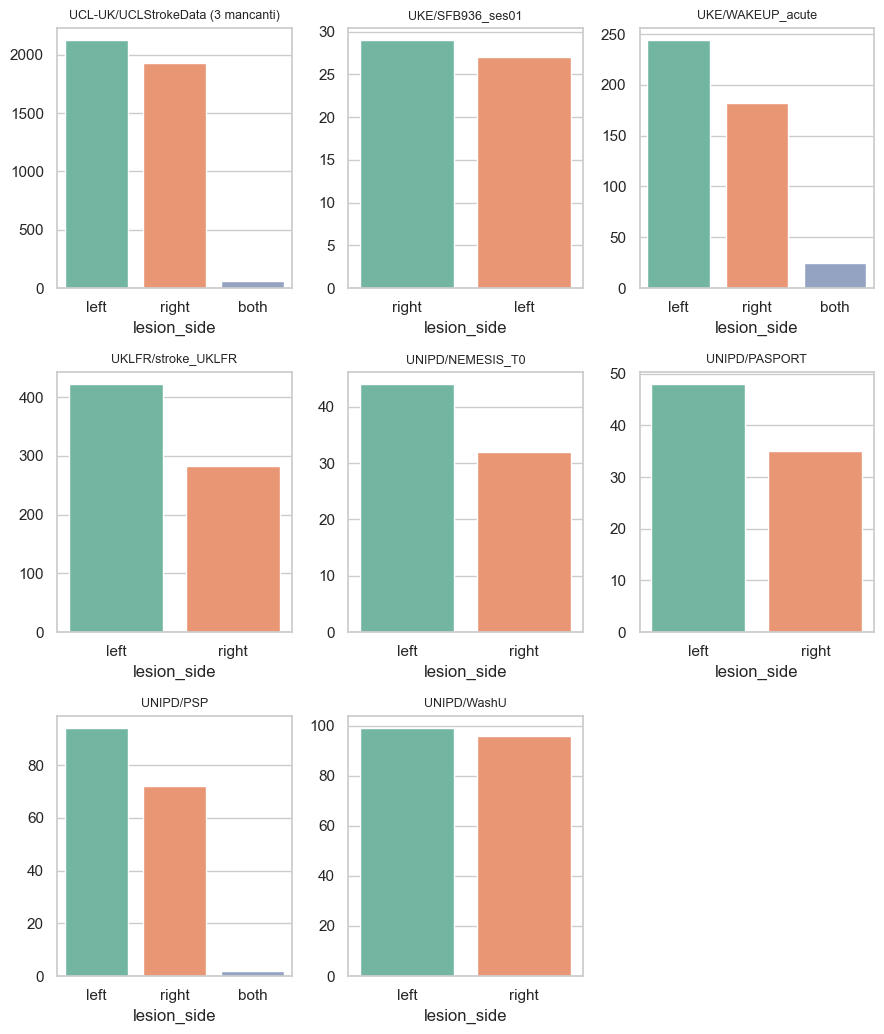

In [27]:
fig, axes = dataset_grid(participants_lesion["dataset"].nunique(), n_cols=3, subplot_size=(3, 3.5))

for ax, (name, group) in zip(axes, participants_lesion.groupby("dataset")):
    counts = group["lesion_side"].value_counts()
    n_missing = group["lesion_side"].isna().sum()
    if counts.empty:
        ax.text(0.5, 0.5, "tutti mancanti", ha="center", va="center")
    else:
        sns.barplot(x=counts.index, y=counts.values, hue=counts.index, legend=False, palette="Set2", ax=ax)
    title = name + (f" ({n_missing} mancanti)" if n_missing else "")
    ax.set_title(title, fontsize=9)

plt.tight_layout()
plt.show();


#### Il lato cambia tra le due griglie?

`lesion_side_*` è attribuito confrontando i voxel ai due lati della midline MNI, con soglia di bilateralità `side_threshold` (0.20 in produzione). Quella soglia è **calibrata solo sulla griglia a 2 mm** (97.4% di accordo su 1445 soggetti con etichetta clinica) e viene applicata anche a 1 mm, dove non è verificata.

Non è ovvio che trasferisca: il piano mediano, escluso da entrambi gli emisferi, è spesso 1 mm su una griglia e 2 mm sull'altra, quindi per una lesione quasi tutta mediana i due indici non sono interscambiabili. Questa cella misura quanto la cosa conti davvero — se i disaccordi sono pochi e concentrati nelle lesioni piccole, la risoluzione non cambia l'attribuzione del lato; se sono molti, la soglia va ricalibrata con `src/pipeline/calibrate_lesion_side_threshold.py --grid 1mm`.

In [ ]:
both_sides = participants_lesion[
    participants_lesion["lesion_side_1mm"].notna() & participants_lesion["lesion_side_2mm"].notna()
]
disagree = both_sides[both_sides["lesion_side_1mm"] != both_sides["lesion_side_2mm"]]

print(f"{len(both_sides)} soggetti con un lato attribuibile su entrambe le griglie")
print(f"{len(disagree)} cambiano lato tra 1 mm e 2 mm ({len(disagree) / max(len(both_sides), 1):.2%})\n")

print("correlazione tra i due indici di lateralita':")
print(both_sides[["laterality_index_1mm", "laterality_index_2mm"]].corr().round(4).to_string())

display(pd.crosstab(both_sides["lesion_side_1mm"], both_sides["lesion_side_2mm"]))

if len(disagree):
    print("\nI disaccordi si concentrano nelle lesioni piccole? (volume a 1 mm)")
    display(pd.DataFrame({
        "in disaccordo": disagree["lesion_volume_voxels_1mm"].describe(),
        "tutti": both_sides["lesion_volume_voxels_1mm"].describe(),
    }).round(1))
    show_scrollable("\n".join(
        f"{r.subject_id}\t{r.dataset}\t1mm={r.lesion_side_1mm} ({r.laterality_index_1mm:+.3f})"
        f"\t2mm={r.lesion_side_2mm} ({r.laterality_index_2mm:+.3f})\t{int(r.lesion_volume_voxels_1mm)} voxel"
        for r in disagree.sort_values("lesion_volume_voxels_1mm").itertuples()
    ))

### Lesione fuori dal brain

**Due modi di gestire i voxel fuori dal cervello, e si combinano**

- **Correzione** (`correct_out_of_brain` in `build_lesion_matrix.py`): si azzerano i voxel fuori dal cervello e il soggetto resta nella matrice con una maschera pulita.
- **Esclusione**: se la frazione fuori dal cervello è troppo alta, correggere non basta — è probabile un errore grave di segmentazione/normalizzazione, non rumore ai bordi — e il soggetto va in `assets/metadata/excluded_subjects.csv` con motivo `out_of_brain_fraction_too_high`.

Le due cose non sono alternative: la correzione è il comportamento di default per tutti, l'esclusione riguarda i casi che la correzione non salva.

**Obiettivo**

Guardare la distribuzione e decidere **quali** soggetti escludere — la cella finale del notebook scrive il file.

**Nota sul calcolo**

La frazione è misurata sulla maschera **grezza**, prima dell'azzeramento: dopo la correzione sarebbe 0 per costruzione. È già calcolata in `lesion_metadata.csv`, una colonna per griglia.

In [ ]:
# Le metriche sono gia' nel frame caricato all'inizio: nessun ricalcolo, nessun file in piu'.
OUT_OF_BRAIN_COLUMN = "out_of_brain_fraction_2mm"  # da modificare per guardare un'altra griglia

out_of_brain_df = participants_lesion[participants_lesion[OUT_OF_BRAIN_COLUMN].notna()]
n_undefined = len(participants_lesion) - len(out_of_brain_df)
print(f"{len(out_of_brain_df)} soggetti con {OUT_OF_BRAIN_COLUMN} definita")
if n_undefined:
    print(f"{n_undefined} esclusi dalla distribuzione: maschera vuota, quindi la frazione non e' definita (NaN, non 0)")

#### Distribuzione

In [ ]:
fig, axes = dataset_grid(out_of_brain_df["dataset"].nunique(), n_cols=3, subplot_size=(4, 3.5))

for ax, (name, group) in zip(axes, out_of_brain_df.groupby("dataset")):
    sns.histplot(group[OUT_OF_BRAIN_COLUMN] * 100, bins=20, color="indianred", ax=ax)
    ax.set_title(f"{name} (n={len(group)})", fontsize=9)
    ax.set_xlabel("% voxel di lesione fuori dal brain")

plt.tight_layout()
plt.show();


#### Soglia di esclusione candidata

**Che cos'è la soglia**

La **frazione massima di voxel di lesione fuori dal cervello** che si è disposti a tollerare per un soggetto. Oltre quel valore il soggetto va escluso a mano, perché la correzione non basterebbe.

**Come si calcola la frazione, per ogni soggetto**

`out_of_brain_fraction = voxel di lesione fuori dalla brain mask / voxel di lesione totali`, sulla maschera grezza.

- `0` = lesione tutta dentro il cervello. `1` = lesione tutta fuori (con `correct_out_of_brain` attiva, quel soggetto finisce con volume 0).
- Un soggetto con maschera vuota ha frazione **`NaN`**, non 0: "nessun voxel fuori dal cervello" e "nessun voxel" sono fatti diversi, e 0 lo metterebbe tra i soggetti più puliti della distribuzione. Quei soggetti sono esclusi da questa sezione e trattati come maschere vuote.
- Regola di esclusione: `frazione > soglia`. Chi sta esattamente sulla soglia resta.

**Come leggere la cella**

Non c'è un test statistico: le soglie candidate sono valori fissi (5%, 10%, 30%, 50%, 70%). Per ognuna la cella mostra quanti soggetti la superano, sul totale, e in quali dataset. Serve a scegliere quali ID mettere nella cella finale, che scrive il file degli esclusi.

In [ ]:
for threshold in [0.05, 0.1, 0.3, 0.5, 0.7]:
    over = out_of_brain_df[out_of_brain_df[OUT_OF_BRAIN_COLUMN] > threshold]
    print(f"\nSoglia > {threshold:.0%} fuori dal brain: {len(over)}/{len(out_of_brain_df)} soggetti")
    if len(over):
        display(over.groupby("dataset").size().rename("n_soggetti").to_frame())


#### ID dei soggetti sopra soglia

**Cosa fa questa cella**

Per ogni soglia della cella sopra, elenca in un riquadro scorrevole gli **ID dei soggetti** con `out_of_brain_fraction` sopra soglia, ordinati per frazione decrescente, con dataset e percentuale — utile per aprire le maschere una a una e giudicare a occhio se è un errore di normalizzazione.

Usa `show_scrollable`, definita nella cella "Soglia IQR per dataset" (da eseguire prima).

In [ ]:
for threshold in [0.05, 0.1, 0.3, 0.5, 0.7]:
    over = out_of_brain_df[out_of_brain_df[OUT_OF_BRAIN_COLUMN] > threshold].sort_values(
        OUT_OF_BRAIN_COLUMN, ascending=False
    )
    print(f"Soglia > {threshold:.0%} fuori dal brain: {len(over)} soggetti")
    if len(over):
        show_scrollable("\n".join(
            f"{r.subject_id}\t{r.dataset}\t{getattr(r, OUT_OF_BRAIN_COLUMN):.1%}" for r in over.itertuples()
        ))

---

## I soggetti esclusi

Questa è la cella che **decide**. Tutto quello che c'è sopra è esplorazione: qui si scrive `assets/metadata/excluded_subjects.csv`, l'unica lista letta sia da `build_lesion_matrix.py` sia da `build_sdc_matrix.py` — quindi le due matrici escludono gli stessi soggetti per costruzione.

Si scrivono **solo gli ID**, raggruppati per motivo. Il `value` di ogni riga (il numero che ha motivato l'esclusione) e il `dataset` vengono ricavati dalle colonne già calcolate, così non possono essere sbagliati a mano.

I tre motivi ammessi sono quelli di `KNOWN_EXCLUSION_REASONS` (`src/utils/participants.py`); un motivo non registrato fa fallire la run delle pipeline di matrice, non questa cella.

**Una lista vuota è una decisione valida** e scrive il file con la sola intestazione: significa "nessuna esclusione, deliberatamente". Un file assente è invece un errore per le pipeline, perché non si distingue da "mai scritto".

In [ ]:
EXCLUDED_SUBJECTS_PATH = Path(project_root) / "assets" / "metadata" / "excluded_subjects.csv"

# Da compilare: gli ID da tenere fuori dalle matrici di produzione, per motivo.
EXCLUSIONS = {
    "empty_mask": [],
    "lesion_too_small": [],
    "out_of_brain_fraction_too_high": [],
}

# Da quale colonna leggere il `value` di ogni riga, per motivo.
VALUE_COLUMN_BY_REASON = {
    "empty_mask": "lesion_volume_voxels_1mm",          # il conteggio nativo: 0 = vuota davvero
    "lesion_too_small": "lesion_volume_voxels_2mm",     # la griglia che entra nella matrice
    "out_of_brain_fraction_too_high": OUT_OF_BRAIN_COLUMN,
}

by_id = participants_lesion.set_index("subject_id")
listed = [s for ids in EXCLUSIONS.values() for s in ids]

duplicated = sorted({s for s in listed if listed.count(s) > 1})
assert not duplicated, f"ID ripetuti sotto motivi diversi (una riga per soggetto): {duplicated}"
unknown = [s for s in listed if s not in by_id.index]
assert not unknown, f"ID non presenti in lesion_metadata.csv: {unknown}"

rows = [
    {
        "subject_id": subject_id,
        "dataset": by_id.loc[subject_id, "dataset"],
        "reason": reason,
        "value": by_id.loc[subject_id, VALUE_COLUMN_BY_REASON[reason]],
    }
    for reason, ids in EXCLUSIONS.items()
    for subject_id in ids
]

excluded = pd.DataFrame(rows, columns=["subject_id", "dataset", "reason", "value"])
excluded.to_csv(EXCLUDED_SUBJECTS_PATH, index=False)

print(f"{len(excluded)} soggetti esclusi scritti in {EXCLUDED_SUBJECTS_PATH}")
if len(excluded):
    display(excluded.groupby(["reason", "dataset"]).size().rename("n_soggetti").to_frame())
    display(excluded)
else:
    print("(sola intestazione: nessuna esclusione, deliberatamente)")